# Fine-tuning LayoutLM on the SROIE Dataset

**References:**
- [Original LayoutLM GitHub repo](https://github.com/microsoft/unilm/tree/master/layoutlm)
- [Fine-tune SROIE on LayoutLM](https://www.kaggle.com/code/ruifcruz/fine-tune-sroie-on-layoutlm) by ruifcruz
- [SROIE dataset (ICDAR 2019)](https://rrc.cvc.uab.es/?ch=13)

**Notes:**
- The dataset lives in `SROIE2019/train/` and `SROIE2019/test/` relative to this notebook.
- Labels extracted: **COMPANY**, **DATE**, **ADDRESS**, **TOTAL**.

## 0. Environment check

Make sure the kernel is **Python 3.11 (LayoutLM)**.  
Run the cell below to confirm.

In [2]:
import sys
print("Python:", sys.version)

import torch
import transformers
import pandas as pd
import numpy as np
import cv2
import matplotlib
import seqeval

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Python: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]


d:\Desktop\Code\USTH\LNP\layoutlm_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.5.1+cu121
Transformers: 5.3.0
CUDA available: True
Device: cuda


## 1. Imports and configuration

In [3]:
import os
import json
import random
from pathlib import Path
from difflib import SequenceMatcher

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display
import matplotlib
from matplotlib import pyplot as plt, patches

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    LayoutLMConfig,
    LayoutLMForTokenClassification,
    LayoutLMTokenizer,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import classification_report, f1_score

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path(os.getcwd())
SROIE_DIR     = NOTEBOOK_DIR / "SROIE2019"
MODEL_DIR     = SROIE_DIR / "layoutlm-base-uncased"
DATASET_DIR   = NOTEBOOK_DIR / "dataset"
OUTPUT_DIR    = NOTEBOOK_DIR / "output"

DATASET_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyper-parameters ─────────────────────────────────────────────────────────
MAX_SEQ_LEN       = 512
TRAIN_BATCH_SIZE  = 8
EVAL_BATCH_SIZE   = 16
NUM_EPOCHS        = 10
LEARNING_RATE     = 5e-5
WARMUP_RATIO      = 0.1
SEED              = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("SROIE folder:", SROIE_DIR.resolve())
print("Model folder:", MODEL_DIR.resolve())

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda
SROIE folder: D:\Desktop\Code\USTH\LNP\SROIE2019
Model folder: D:\Desktop\Code\USTH\LNP\SROIE2019\layoutlm-base-uncased


## 2. Pre-processing the SROIE dataset

### 2.1 Read bounding boxes + words

In [4]:
def read_bbox_and_words(path: Path) -> pd.DataFrame:
    """Parse a SROIE OCR .txt file into a DataFrame with bounding boxes and text."""
    rows = []
    with open(path, "r", errors="ignore") as f:
        for line in f.read().splitlines():
            if not line.strip():
                continue
            parts = line.split(",")
            if len(parts) < 9:
                continue
            try:
                coords = list(map(int, parts[:8]))
            except ValueError:
                continue
            text = ",".join(parts[8:])
            # Keep only top-left (x0,y0) and bottom-right (x2,y2)
            rows.append([path.stem, coords[0], coords[1], coords[4], coords[5], text])

    df = pd.DataFrame(rows, columns=["filename", "x0", "y0", "x2", "y2", "line"])
    return df


# ── Demo ─────────────────────────────────────────────────────────────────────
example_stem = "X51005365187"
demo_bbox_path = SROIE_DIR / "test" / "box" / f"{example_stem}.txt"
if demo_bbox_path.exists():
    demo_bbox = read_bbox_and_words(demo_bbox_path)
    print("Bounding-box DataFrame (first 5 rows):")
    display(demo_bbox.head())
else:
    print(f"Demo file not found: {demo_bbox_path}")

Bounding-box DataFrame (first 5 rows):


,filename,x0,y0,x2,y2,line
0,X51005365187,17,35,371,91,3-1707067
1,X51005365187,222,115,511,143,F&P PHARMACY
2,X51005365187,274,148,457,174,(002309592-P)
3,X51005365187,204,183,529,210,"NO.20. GROUND FLOOR,"
4,X51005365187,99,218,632,244,"JALAN BS 10/6 TAMAN BUKIT SERDANG,"


### 2.2 Read entities

In [5]:
def read_entities(path: Path) -> pd.DataFrame:
    """Load the JSON entities file for a receipt."""
    with open(path, "r", errors="ignore") as f:
        data = json.load(f)
    return pd.DataFrame([data])


# ── Demo ─────────────────────────────────────────────────────────────────────
demo_entities_path = SROIE_DIR / "test" / "entities" / f"{example_stem}.txt"
if demo_entities_path.exists():
    demo_entities = read_entities(demo_entities_path)
    print("Entities DataFrame:")
    display(demo_entities)
else:
    print(f"Demo file not found: {demo_entities_path}")

Entities DataFrame:


,company,date,address,total
0,F&P PHARMACY,02/03/2018,"NO.20. GROUND FLOOR, JALAN BS 10/6 TAMAN BUKIT...",31.90


### 2.3 Assign labels to lines

In [6]:
def assign_line_label(line: str, entities: pd.DataFrame) -> str:
    """Match a text line against entity values using fuzzy similarity."""
    line_set = line.replace(",", "").strip().split()
    for col_idx, column in enumerate(entities.columns):
        entity_value = entities.iloc[0, col_idx].replace(",", "").strip()
        entity_set   = entity_value.split()

        matches = sum(
            1 for w in line_set
            if any(SequenceMatcher(a=w, b=b).ratio() > 0.8 for b in entity_set)
        )

        col_upper = column.upper()
        if (
            (col_upper == "ADDRESS" and len(line_set) > 0 and (matches / len(line_set)) >= 0.5)
            or (col_upper != "ADDRESS" and matches == len(line_set))
            or matches == len(entity_set)
        ):
            return col_upper
    return "O"


def assign_labels(words: pd.DataFrame, entities: pd.DataFrame) -> pd.DataFrame:
    """Label every line in *words* using the receipt entities."""
    max_area     = {"TOTAL": (0, -1), "DATE": (0, -1)}
    seen_labels  = {"TOTAL": False, "DATE": False,
                    "ADDRESS": False, "COMPANY": False, "O": False}

    labels = []
    for i, line in enumerate(words["line"]):
        label = assign_line_label(line, entities)
        seen_labels[label] = True

        if (label == "ADDRESS" and seen_labels["TOTAL"]) or \
           (label == "COMPANY" and (seen_labels["DATE"] or seen_labels["TOTAL"])):
            label = "O"

        if label in ("TOTAL", "DATE"):
            x0_loc = words.columns.get_loc("x0")
            bbox   = words.iloc[i, x0_loc: x0_loc + 4].tolist()
            area   = (bbox[2] - bbox[0]) + (bbox[3] - bbox[1])
            if max_area[label][0] < area:
                max_area[label] = (area, i)
            label = "O"

        labels.append(label)

    if max_area["DATE"][1] >= 0:
        labels[max_area["DATE"][1]]  = "DATE"
    if max_area["TOTAL"][1] >= 0:
        labels[max_area["TOTAL"][1]] = "TOTAL"

    words = words.copy()
    words["label"] = labels
    return words


# ── Demo ─────────────────────────────────────────────────────────────────────
if demo_bbox_path.exists() and demo_entities_path.exists():
    demo_labeled = assign_labels(demo_bbox, demo_entities)
    display(demo_labeled.head(15))

,filename,x0,y0,x2,y2,line,label
0,X51005365187,17,35,371,91,3-1707067,O
1,X51005365187,222,115,511,143,F&P PHARMACY,COMPANY
2,X51005365187,274,148,457,174,(002309592-P),O
3,X51005365187,204,183,529,210,"NO.20. GROUND FLOOR,",ADDRESS
4,X51005365187,99,218,632,244,"JALAN BS 10/6 TAMAN BUKIT SERDANG,",ADDRESS
5,X51005365187,111,250,623,275,"SEKSYEN 10, 43300 SERI KEMBANGAN,",ADDRESS
6,X51005365187,186,284,538,308,SELANGOR DARUL EHSAN,ADDRESS
7,X51005365187,251,316,484,339,TEL 03-89599823,O
8,X51005365187,182,351,346,378,GST REG NO,O
9,X51005365187,274,387,461,409,TAX INVOICE,O


### 2.4 Split lines into individual word tokens

In [7]:
def split_line(row: pd.Series) -> list:
    """Split a multi-word line into individual-word rows, distributing the bbox proportionally."""
    row   = row.copy()
    words = [w for w in row["line"].split() if len(w) >= 1]
    if not words:
        return []

    x0, y0, x2, y2 = int(row["x0"]), int(row["y0"]), int(row["x2"]), int(row["y2"])
    total_len       = sum(len(w) for w in words)
    if total_len == 0:
        return []

    bbox_width = x2 - x0
    new_rows   = []
    cur_x      = x0
    for word in words:
        word_x2 = cur_x + int(bbox_width * len(word) / total_len)
        new_row  = row.copy()
        new_row["x0"]  = cur_x
        new_row["x2"]  = word_x2
        new_row["line"] = word
        new_rows.append(new_row.tolist())
        cur_x = word_x2 + 5
    return new_rows


# ── Demo ─────────────────────────────────────────────────────────────────────
if demo_bbox_path.exists() and demo_entities_path.exists():
    split_result = split_line(demo_labeled.loc[1])
    pd.DataFrame(split_result, columns=demo_labeled.columns)

### 2.5 Build full dataset

In [8]:
def build_dataset(folder: Path) -> list:
    """
    Read all receipts from *folder* (which must contain box/, entities/, img/).
    Returns a list of (DataFrame, image_width, image_height) tuples.
    """
    bbox_files     = sorted((folder / "box").glob("*.txt"))
    entities_files = sorted((folder / "entities").glob("*.txt"))
    img_files      = sorted((folder / "img").glob("*.jpg"))

    # Filter to stems that have all three files
    bbox_stems     = {p.stem for p in bbox_files}
    entities_stems = {p.stem for p in entities_files}
    img_stems      = {p.stem for p in img_files}
    common_stems   = sorted(bbox_stems & entities_stems & img_stems)

    bbox_map     = {p.stem: p for p in bbox_files}
    entities_map = {p.stem: p for p in entities_files}
    img_map      = {p.stem: p for p in img_files}

    data = []
    for stem in tqdm(common_stems, desc=f"Reading {folder.name}"):
        try:
            bbox     = read_bbox_and_words(bbox_map[stem])
            entities = read_entities(entities_map[stem])
            image    = Image.open(img_map[stem])
        except Exception as e:
            print(f"  Skipping {stem}: {e}")
            continue

        # Ensure all required entity columns exist
        for col in ["company", "date", "address", "total"]:
            if col not in entities.columns:
                entities[col] = ""

        bbox_labeled = assign_labels(bbox, entities)

        # Split lines → words
        word_rows = []
        for _, row in bbox_labeled.iterrows():
            word_rows.extend(split_line(row))

        if not word_rows:
            continue

        word_df = pd.DataFrame(word_rows, columns=bbox_labeled.columns)

        # Refine labels: add S- prefix only when word truly matches entity
        refined_labels = []
        for _, row in word_df.iterrows():
            label = row["label"]
            if label != "O":
                entity_val = entities.iloc[0][label.lower()]
                entity_set = entity_val.split()
                if any(SequenceMatcher(a=row["line"], b=b).ratio() > 0.7 for b in entity_set):
                    label = "S-" + label
                else:
                    label = "O"
            refined_labels.append(label)

        word_df = word_df.copy()
        word_df["label"] = refined_labels

        w, h = image.size
        data.append((word_df, w, h))

    return data


print("Building TRAIN dataset ...")
dataset_train = build_dataset(SROIE_DIR / "train")
print(f"  {len(dataset_train)} receipts loaded.")

print("Building TEST dataset ...")
dataset_test = build_dataset(SROIE_DIR / "test")
print(f"  {len(dataset_test)} receipts loaded.")

Building TRAIN dataset ...


Reading train: 100%|██████████| 626/626 [00:31<00:00, 20.12it/s]


  626 receipts loaded.
Building TEST dataset ...


Reading test: 100%|██████████| 347/347 [00:16<00:00, 20.76it/s]

  347 receipts loaded.


### 2.6 Write pre-processed files

In [9]:
def normalize_bbox(x0, y0, x2, y2, width, height):
    """Normalize coordinates to [0, 1000] range, clamped and sorted."""
    nx0 = max(0, min(int(1000 * x0 / width),  1000))
    ny0 = max(0, min(int(1000 * y0 / height), 1000))
    nx2 = max(0, min(int(1000 * x2 / width),  1000))
    ny2 = max(0, min(int(1000 * y2 / height), 1000))
    # Guarantee x0 ≤ x2 and y0 ≤ y2 so derived w/h are non-negative
    return [min(nx0, nx2), min(ny0, ny2), max(nx0, nx2), max(ny0, ny2)]


def write_dataset(dataset: list, output_dir: Path, split: str):
    """
    Write three files:
      {split}.txt       — word <TAB> label
      {split}_box.txt   — word <TAB> norm_x0 norm_y0 norm_x2 norm_y2
      {split}_image.txt — word <TAB> raw_bbox <TAB> width height <TAB> filename
    """
    txt_path   = output_dir / f"{split}.txt"
    box_path   = output_dir / f"{split}_box.txt"
    image_path = output_dir / f"{split}_image.txt"

    with open(txt_path, "w", encoding="utf-8") as f_txt, \
         open(box_path, "w", encoding="utf-8") as f_box, \
         open(image_path, "w", encoding="utf-8") as f_img:

        for word_df, width, height in tqdm(dataset, desc=f"Writing {split}"):
            filename = word_df.iloc[0]["filename"]
            for _, row in word_df.iterrows():
                x0, y0, x2, y2 = int(row["x0"]), int(row["y0"]), int(row["x2"]), int(row["y2"])
                norm = normalize_bbox(x0, y0, x2, y2, width, height)
                word  = row["line"]
                label = row["label"]

                f_txt.write(f"{word}\t{label}\n")
                f_box.write(f"{word}\t{norm[0]} {norm[1]} {norm[2]} {norm[3]}\n")
                f_img.write(f"{word}\t{x0} {y0} {x2} {y2}\t{width} {height}\t{filename}\n")

            f_txt.write("\n")
            f_box.write("\n")
            f_img.write("\n")


write_dataset(dataset_train, DATASET_DIR, "train")
write_dataset(dataset_test,  DATASET_DIR, "test")

# Write labels file
LABELS = ["S-COMPANY", "S-DATE", "S-ADDRESS", "S-TOTAL", "O"]
with open(DATASET_DIR / "labels.txt", "w") as f:
    f.write("\n".join(LABELS))

print("\nDataset files written to:", DATASET_DIR)
for p in sorted(DATASET_DIR.glob("*")):
    print(" ", p.name)


Writing test: 100%|██████████| 347/347 [00:01<00:00, 217.20it/s]


Dataset files written to: d:\Desktop\Code\USTH\LNP\dataset
  labels.txt
  test.txt
  test_box.txt
  test_image.txt
  train.txt
  train_box.txt
  train_image.txt


## 3. Build PyTorch Dataset

We feed the pre-processed text files directly into a custom `Dataset` for LayoutLM token classification.

In [10]:
def read_labeled_examples(txt_path: Path, box_path: Path):
    """
    Read word/label and bbox files, yielding per-receipt lists of
    (words, bboxes, labels).
    """
    examples = []
    words, bboxes, labels = [], [], []

    with open(txt_path, encoding="utf-8") as ft, \
         open(box_path, encoding="utf-8") as fb:

        for line_t, line_b in zip(ft, fb):
            line_t = line_t.rstrip("\n")
            line_b = line_b.rstrip("\n")

            if line_t == "":       # blank line = receipt boundary
                if words:
                    examples.append((words, bboxes, labels))
                words, bboxes, labels = [], [], []
                continue

            parts_t = line_t.split("\t")
            parts_b = line_b.split("\t")
            if len(parts_t) < 2 or len(parts_b) < 2:
                continue

            word  = parts_t[0]
            label = parts_t[1]
            bbox  = list(map(int, parts_b[1].split()))

            words.append(word)
            bboxes.append(bbox)
            labels.append(label)

    if words:
        examples.append((words, bboxes, labels))

    return examples


train_examples = read_labeled_examples(DATASET_DIR / "train.txt",     DATASET_DIR / "train_box.txt")
test_examples  = read_labeled_examples(DATASET_DIR / "test.txt",      DATASET_DIR / "test_box.txt")
print(f"Train receipts: {len(train_examples)}, Test receipts: {len(test_examples)}")

Train receipts: 626, Test receipts: 347


In [11]:
class SROIEDataset(Dataset):
    """
    Converts the pre-processed SROIE examples into LayoutLM-ready tensors.
    Each sample is a single receipt truncated / padded to MAX_SEQ_LEN.
    """

    def __init__(self, examples, tokenizer, label2id, max_len=512):
        self.tokenizer = tokenizer
        self.label2id  = label2id
        self.max_len   = max_len
        self.features  = self._convert(examples)

    @staticmethod
    def _clamp_bbox(bbox):
        """Clamp bbox to [0, 1000] and ensure x0 ≤ x2, y0 ≤ y2."""
        x0 = max(0, min(bbox[0], 1000))
        y0 = max(0, min(bbox[1], 1000))
        x2 = max(0, min(bbox[2], 1000))
        y2 = max(0, min(bbox[3], 1000))
        return [min(x0, x2), min(y0, y2), max(x0, x2), max(y0, y2)]

    def _convert(self, examples):
        features = []
        pad_id    = self.tokenizer.pad_token_id
        pad_label = self.label2id["O"]

        for words, bboxes, labels in tqdm(examples, desc="Tokenising"):
            token_ids, token_bboxes, token_labels = [], [], []

            for word, bbox, label in zip(words, bboxes, labels):
                sub_ids = self.tokenizer.convert_tokens_to_ids(
                    self.tokenizer.tokenize(word)
                )
                if not sub_ids:
                    continue
                safe_bbox = self._clamp_bbox(bbox)
                token_ids.extend(sub_ids)
                token_bboxes.extend([safe_bbox] * len(sub_ids))
                # Only the first sub-token gets the real label; rest get -100
                token_labels.append(self.label2id.get(label, self.label2id["O"]))
                token_labels.extend([-100] * (len(sub_ids) - 1))

            # Truncate to max_len - 2 (for [CLS] and [SEP])
            max_tokens = self.max_len - 2
            token_ids    = token_ids[:max_tokens]
            token_bboxes = token_bboxes[:max_tokens]
            token_labels = token_labels[:max_tokens]

            # Add special tokens
            cls_id = self.tokenizer.cls_token_id
            sep_id = self.tokenizer.sep_token_id
            token_ids    = [cls_id] + token_ids + [sep_id]
            token_bboxes = [[0, 0, 0, 0]] + token_bboxes + [[1000, 1000, 1000, 1000]]
            token_labels = [-100] + token_labels + [-100]

            # Attention mask before padding
            seq_len      = len(token_ids)
            attention    = [1] * seq_len

            # Pad
            pad_len = self.max_len - seq_len
            token_ids    += [pad_id]      * pad_len
            token_bboxes += [[0,0,0,0]]   * pad_len
            token_labels += [-100]        * pad_len
            attention    += [0]           * pad_len

            features.append({
                "input_ids":      torch.tensor(token_ids,    dtype=torch.long),
                "bbox":           torch.tensor(token_bboxes, dtype=torch.long),
                "attention_mask": torch.tensor(attention,    dtype=torch.long),
                "labels":         torch.tensor(token_labels, dtype=torch.long),
            })
        return features

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]


# ── Init tokenizer and datasets ───────────────────────────────────────────────
tokenizer = LayoutLMTokenizer.from_pretrained(str(MODEL_DIR))

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}
print("label2id:", label2id)

train_dataset = SROIEDataset(train_examples, tokenizer, label2id, max_len=MAX_SEQ_LEN)
test_dataset  = SROIEDataset(test_examples,  tokenizer, label2id, max_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=EVAL_BATCH_SIZE,  shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


label2id: {'S-COMPANY': 0, 'S-DATE': 1, 'S-ADDRESS': 2, 'S-TOTAL': 3, 'O': 4}


Tokenising: 100%|██████████| 347/347 [00:01<00:00, 305.70it/s]

Train batches: 79, Test batches: 22


## 4. Load LayoutLM model

The pre-trained checkpoint stores weights under `bert.*` keys (older library format).  
We remap them to the `layoutlm.*` prefix that `LayoutLMForTokenClassification` expects.

In [12]:
import collections

config = LayoutLMConfig.from_pretrained(
    str(MODEL_DIR),
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)

# Build a fresh model with the correct architecture
model = LayoutLMForTokenClassification(config)

# Load the raw checkpoint and remap  bert.* → layoutlm.*
# (the checkpoint was saved as LayoutLMForMaskedLM in an older library version)
ckpt_path = MODEL_DIR / "pytorch_model.bin"
raw_state  = torch.load(str(ckpt_path), map_location="cpu")

remapped = collections.OrderedDict()
for key, val in raw_state.items():
    if key.startswith("bert."):
        remapped["layoutlm." + key[len("bert."):]] = val
    elif key.startswith("cls."):
        pass  # discard the pre-training MLM head
    else:
        remapped[key] = val

missing, unexpected = model.load_state_dict(remapped, strict=False)
print(f"Missing  keys : {len(missing)}   (classifier layer — expected for fine-tuning)")
print(f"Unexpected keys: {len(unexpected)}")

model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready. Trainable parameters: {total_params:,}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_19712\679365332.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_state  = torch.load(str(ckpt_path), map_location="cpu")


Missing  keys : 2   (classifier layer — expected for fine-tuning)
Unexpected keys: 0
Model ready. Trainable parameters: 112,631,813


## 5. Training

In [13]:
total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total optimisation steps: {total_steps}  (warmup: {warmup_steps})")

Total optimisation steps: 790  (warmup: 79)


In [14]:
def evaluate(model, loader, id2label):
    """Compute token-level NER metrics on *loader*."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            input_ids      = batch["input_ids"].to(DEVICE)
            bbox           = batch["bbox"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)

            outputs    = model(input_ids=input_ids, bbox=bbox,
                               attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds      = torch.argmax(outputs.logits, dim=-1)

            for p_seq, l_seq in zip(preds.cpu().numpy(), labels.cpu().numpy()):
                pred_row, true_row = [], []
                for p, l in zip(p_seq, l_seq):
                    if l == -100:
                        continue
                    pred_row.append(id2label[p])
                    true_row.append(id2label[l])
                all_preds.append(pred_row)
                all_labels.append(true_row)

    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds)
    return avg_loss, f1, all_labels, all_preds


# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_f1s = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}"):
        optimizer.zero_grad()

        input_ids      = batch["input_ids"].to(DEVICE)
        bbox           = batch["bbox"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        outputs = model(input_ids=input_ids, bbox=bbox,
                        attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_f1, _, _ = evaluate(model, test_loader, id2label)

    train_losses.append(avg_train_loss)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch:2d} | train_loss={avg_train_loss:.4f} "
          f"| val_loss={val_loss:.4f} | val_F1={val_f1:.4f}")

print("\nTraining complete.")

Epoch 1/10: 100%|██████████| 79/79 [06:35<00:00,  5.01s/it]


Epoch  1 | train_loss=0.5412 | val_loss=0.0896 | val_F1=0.9185


Epoch 2/10: 100%|██████████| 79/79 [06:36<00:00,  5.02s/it]


Epoch  2 | train_loss=0.0519 | val_loss=0.0522 | val_F1=0.9489


Epoch 3/10: 100%|██████████| 79/79 [06:37<00:00,  5.03s/it]


...

Epoch  8 | train_loss=0.0055 | val_loss=0.0711 | val_F1=0.9555


Epoch 9/10: 100%|██████████| 79/79 [06:40<00:00,  5.07s/it]


Epoch  9 | train_loss=0.0042 | val_loss=0.0706 | val_F1=0.9568


Epoch 10/10: 100%|██████████| 79/79 [06:37<00:00,  5.03s/it]
                                                     

Epoch 10 | train_loss=0.0035 | val_loss=0.0733 | val_F1=0.9566

Training complete.


## 6. Training curves

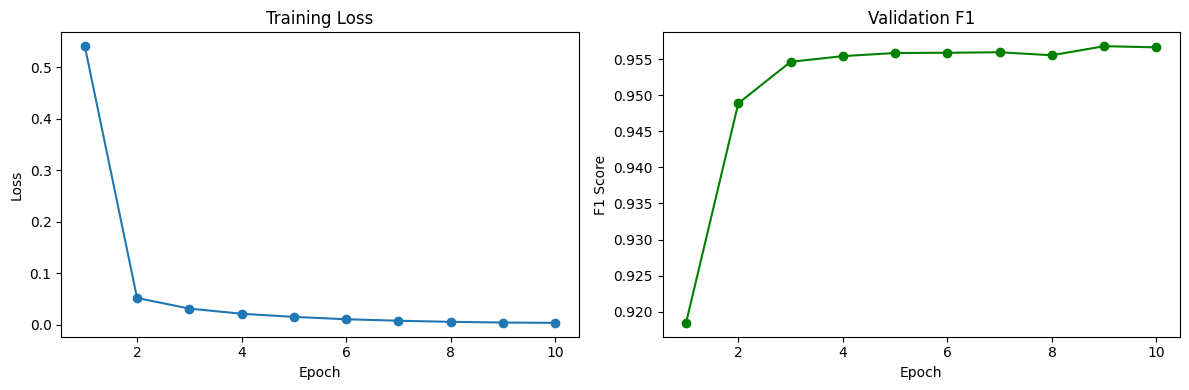

Best F1: 0.9568 at epoch 9


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses)+1), train_losses, marker="o")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(range(1, len(val_f1s)+1), val_f1s, marker="o", color="green")
ax2.set_title("Validation F1")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Score")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=100)
plt.show()
print(f"Best F1: {max(val_f1s):.4f} at epoch {val_f1s.index(max(val_f1s))+1}")

## 7. Final evaluation on the test set

In [16]:
test_loss, test_f1, true_seqs, pred_seqs = evaluate(model, test_loader, id2label)

print(f"Test loss : {test_loss:.4f}")
print(f"Test F1   : {test_f1:.4f}")
print()
print(classification_report(true_seqs, pred_seqs))

Test loss : 0.0733
Test F1   : 0.9566

              precision    recall  f1-score   support

     ADDRESS       0.98      0.99      0.98      3806
     COMPANY       0.91      0.99      0.95      1441
        DATE       0.95      0.98      0.96       409
       TOTAL       0.73      0.72      0.72       358

   micro avg       0.94      0.97      0.96      6014
   macro avg       0.89      0.92      0.90      6014
weighted avg       0.94      0.97      0.96      6014



## 8. Save model & predictions

In [17]:
model.save_pretrained(str(OUTPUT_DIR / "model"))
tokenizer.save_pretrained(str(OUTPUT_DIR / "model"))
print("Model saved to:", OUTPUT_DIR / "model")

# Flatten predictions and write test_predictions.txt
pred_path = OUTPUT_DIR / "test_predictions.txt"
with open(pred_path, "w", encoding="utf-8") as f:
    for p_seq, t_seq in zip(pred_seqs, true_seqs):
        for p, t in zip(p_seq, t_seq):
            f.write(f"{t} {p}\n")
        f.write("\n")
print("Predictions saved to:", pred_path)

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.86s/it]

Model saved to: d:\Desktop\Code\USTH\LNP\output\model
Predictions saved to: d:\Desktop\Code\USTH\LNP\output\test_predictions.txt


## 9. Visualise predictions on sample receipts

In [18]:
# Load raw image coords (needed for pixel-level drawing)
img_info_path = DATASET_DIR / "test_image.txt"
label_path    = DATASET_DIR / "test.txt"

img_df    = pd.read_csv(img_info_path, sep="\t",
                        names=["word", "bbox", "size", "filename"])
label_df  = pd.read_csv(label_path,   sep="\t",
                        names=["word", "true_label"])

# Flatten pred_seqs into a single list aligned with label_df rows
flat_preds = []
for p_seq in pred_seqs:
    flat_preds.extend(p_seq)

# label_df has blank rows between receipts; drop them for alignment
label_df_clean = label_df.dropna(subset=["true_label"]).reset_index(drop=True)
img_df_clean   = img_df.dropna(subset=["bbox"]).reset_index(drop=True)

min_len   = min(len(label_df_clean), len(img_df_clean), len(flat_preds))
merged    = img_df_clean.iloc[:min_len].copy()
merged["true_label"] = label_df_clean["true_label"].values[:min_len]
merged["pred_label"] = flat_preds[:min_len]

receipt_groups = list(merged.groupby("filename"))
print(f"{len(receipt_groups)} receipt groups found.")

347 receipt groups found.


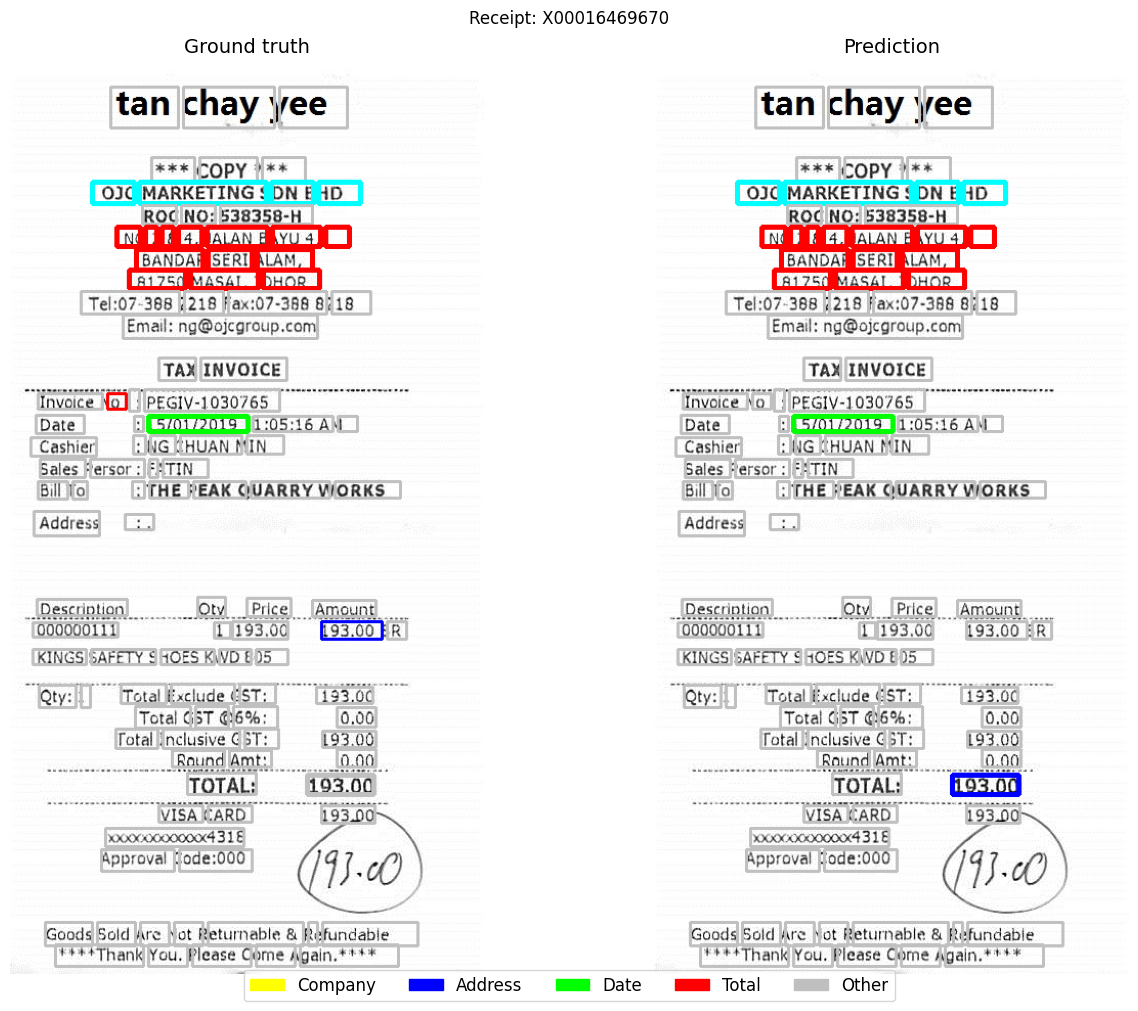

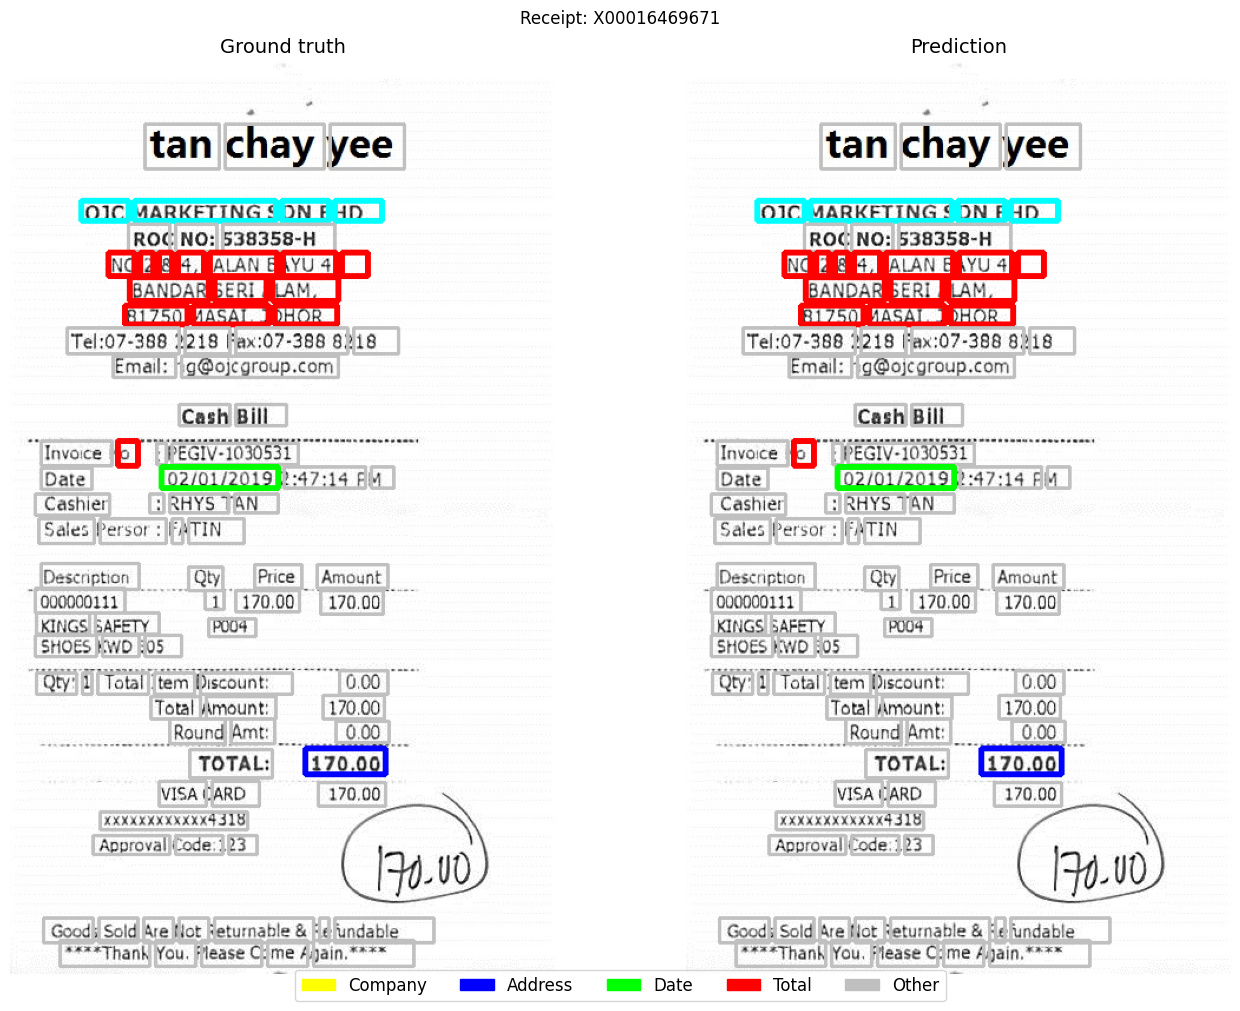

In [19]:
COLORS = {
    "S-TOTAL":   (255,   0,   0),
    "S-DATE":    (  0, 255,   0),
    "S-ADDRESS": (  0,   0, 255),
    "S-COMPANY": (255, 255,   0),
    "O":         (192, 192, 192),
}


def display_receipt(group_item, img_folder: Path):
    filename, group = group_item
    img_path = img_folder / (str(filename).split(".")[0] + ".jpg")

    if not img_path.exists():
        print(f"Image not found: {img_path}")
        return

    img_orig = cv2.imread(str(img_path))
    img_pred = img_orig.copy()

    for _, row in group.iterrows():
        try:
            x1, y1, x2, y2 = map(int, str(row["bbox"]).split())
        except Exception:
            continue
        true_col = COLORS.get(row["true_label"], COLORS["O"])
        pred_col = COLORS.get(row["pred_label"], COLORS["O"])
        thick    = 2 if row["pred_label"] == "O" else 4
        cv2.rectangle(img_orig, (x1, y1), (x2, y2), true_col, thick)
        cv2.rectangle(img_pred, (x1, y1), (x2, y2), pred_col, thick)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))
    ax1.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
    ax1.set_title("Ground truth", fontsize=14)
    ax1.axis("off")
    ax2.imshow(cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB))
    ax2.set_title("Prediction",    fontsize=14)
    ax2.axis("off")

    legend_handles = [
        patches.Patch(color=(1,1,0),   label="Company"),
        patches.Patch(color=(0,0,1),   label="Address"),
        patches.Patch(color=(0,1,0),   label="Date"),
        patches.Patch(color=(1,0,0),   label="Total"),
        patches.Patch(color=(0.75,0.75,0.75), label="Other"),
    ]
    fig.legend(handles=legend_handles, fontsize=12, loc="lower center",
               ncol=5, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(f"Receipt: {filename}", fontsize=12)
    plt.tight_layout()
    plt.show()


# Show the first two receipts
IMG_FOLDER = SROIE_DIR / "test" / "img"
for group in receipt_groups[:2]:
    display_receipt(group, IMG_FOLDER)